In [3]:
import pandas as pd
import numpy as np
import datetime as dt

# 날짜와 시간의 연산

모든 데이터 분석이 그렇지만 데이터 분석을 위해서는 분석 대상 데이터를 가져온 이후, 데이터의 모델링과 분석, 예측에 적합하도록 데이터를 전처리 해야 한다. 일반적 수치 데이터(numerical data), 문자 데이터(character data), 범주형 데이터(categorical data) 등과 달리 시계열 데이터는 달력 상의 날짜에 대한 연산 처리, 24시간, 60분과 같은 일정치 않은 주기에 대한 연산이 필요하다. python에서 날짜와 시간에 대한 연산이 어떻게 수행되는지를 이해하기 위해서는 날짜와 시간의 연산에 사용되는 데이터 클래스인 dateoffset, timedelta, peroid를 이해해야 한다. 

## dateoffset을 사용한 연산

dateoffset은 pandas에서 제공하는 날짜와 시간의 간격을 표현하는데 전용으로 사용되는 데이터 클래스이다. dateoffset은 달력상의 날짜와 시간을 기반으로 두 날짜나 시간 간의 차이를 표현하는데 특정 두 시점의 시작부터 끝까지의 차이가 아닌 일반적인 날짜와 시간의 간격을 의미한다. DateOffset은 "days", "weeks", "years"와 같은 키워드를 사용하여 날짜를 일, 주, 년씩 증가시키거나 감소시킬수 있다. dateoffset을 생성하기 위해서는 pandas의 `dateoffset()`을 사용하여 생성할 수 있는데, 다음은 `dataoffset()`에서 날짜 간격을 설정하는데 사용하는 주요 매개변수이다. 
|키워드|주기|
|---|---|
|years|연도|
|months|월|
|weeks|주|
|days|일|
|hours|시간|
|minutes|분|
|seconds|초|
|milliseconds|밀리초|
|microseconds|마이크로초|
|nanoseconds|나노초|

dateoffset에서는 유용한 서브 클래스를 제공한다. 이중 매우 유용하게 사용되는 서브 클래스는 달력상의 날짜가 아닌 영업일 상의 날짜와 시간을 계산하는 business 관련 dateoffset이다. 주요 business 관련 dateoffset의 서브 클래스는 다음과 같다.
|서브 클래스 명|설명|별칭|주요 속성|주요 메쏘드|
|---|---|---|---|---|
|BusinessDay|영업일을 표현하는데 사용되는 서브 클래스|BDay|freqstr, name, holidays|copy(), is_on_offset(), is_month_start(), is_month_end()|
|BusinessHour|영업시간을 표현하는데 사용되는 서브 클래스||freqstr, name, next_bday|copy(), is_on_offset(), is_month_start(), is_month_end(), rollback(), rollforward()|
|FY5253|52-53주의 회계 연도를 표현하는데 사용되는 서브 클래스||freqstr, name|copy(), is_month_start(), is_month_end(), rollback(), rollforward()|

다음은 dateoffset의 서브 클래스인 BusinessDay를 사용하는 예를 보이고 있다. 2023년 2월 5일은 일요일이기 때문에 영업일 2일 전은 토요일과 일요일이 포함되지 않은 목요일로 결과를 산출하게 된다. 

In [5]:
dt = pd.to_datetime( '2023-2-05' ) 
print ( '원래 값: ' , dt, dt.day_name()) 
print ( 'DateOffset 사용: ' , dt + BusinessDay(-2), (dt + BDay(-2)).day_name())

원래 값:  2023-02-05 00:00:00 Sunday
DateOffset 사용:  2023-02-02 00:00:00 Thursday


dateoffset을 사용하여 날짜와 시간의 연산은 다음과 같다. 

### dateoffset의 더하기, 빼기

시간의 더하기와 빼기는 더하거나 뺄 시간의 오프셋을 DateOffset으로 설정한 후 '+', '-' 연산 기호를 사용하여 계산한다. 

In [37]:
from pandas.tseries.offsets import * 
dt = pd.to_datetime( '2023-2-05' ) 
print ( '원래 값: ' , dt) 
print ( 'DateOffset 사용: ' , dt + DateOffset(weeks= 2 ))

원래 값:  2023-02-05 00:00:00
DateOffset 사용:  2023-02-19 00:00:00


앞의 코드를 보면 먼저 pandas.tseries.offsets 모듈에서 pandas와 DateOffset 클래스를 로딩 한 다음 to_datetime()를 사용핸 만든 datetime 개체에 하루의 DateOffset을 추가하고 결과 Timestamp 개체를 출력했다.
다음은 앞선 예와는 반대로 2개월 앞선 날을 산출하는 코드이다. 

In [3]:
dt = pd.to_datetime( '2023-2-05' ) 
print ( '원래 값: ' , dt) 
print ( 'DateOffset 사용: ' , dt + DateOffset(months= -2))

원래 값:  2023-02-05 00:00:00
DateOffset 사용:  2022-12-05 00:00:00


### dateoffset의 벡터 연산

DateOffset은 시점 데이터인 스칼라 시점 데이터 뿐만 아니라 DatetimeIndex와 같이 벡터 데이터에 대한 연산도 가능하다.  

In [21]:
pd.date_range(start = '2023-02-05', periods = 10, freq = 'D') + DateOffset(weeks = 10)

DatetimeIndex(['2023-04-16', '2023-04-17', '2023-04-18', '2023-04-19',
               '2023-04-20', '2023-04-21', '2023-04-22', '2023-04-23',
               '2023-04-24', '2023-04-25'],
              dtype='datetime64[ns]', freq=None)

### 특정 월의 시작일과 끝일의 산출

Timestamp로 설정된 특정 시점 월의 시작 일과 마지막 일을 산출하기 위해서는 DateOffset의 `MonthBegin()`과 `MonthEnd()`를 산술 연산자인 '+', '-'로 적용하여 사용할 수 있다. `MonthBegin()`에 '+' 연산이 적용되면 다음 월의 시작 일, '-' 연산이 적용되면 해당월의 시작 일이 리턴되고, `MonthEnd()`에 '+' 연산이 적용되면 해당 월의 마지막 일, '-' 연산을 적용하면 전 월의 마지막 일이 리턴된다.  

In [25]:
pd.Timestamp("2023/02/05") + pd.offsets.MonthBegin()

Timestamp('2023-03-01 00:00:00')

In [26]:
pd.Timestamp("2023/02/05") - pd.offsets.MonthEnd()

Timestamp('2023-01-31 00:00:00')

### 사용자 정의 영업일 설정

DateOffset의 서브 클래스인 BusinessDay에서 디폴트로 설정된 영업일은 월요일부터 금요일까지이다. 하지만 경우에 따라 영업일이 이와 다를 수 있다. 이를 설정하기 위해 사용하는 함수는 `CustomBusinessDay()`, 매개변수는 'weekmask'이다. 예를 들어 특정 업체의 휴일이 목요일과 금요일이라면 'weekmask'에 월, 화, 수, 토, 일요일을 리스트로 다음과 같이 설정한다. 

In [34]:
dt = pd.to_datetime('2023-2-06') 
print ( '원래 값: ' , dt, dt.day_name()) 
print ( 'DateOffset 사용: ', dt + pd.offsets.CustomBusinessDay(3, weekmask='Mon Tue Thu Sat Sun'), 
      (dt + pd.offsets.CustomBusinessDay(3, weekmask='Mon Tue Thu Sat Sun')).day_name())

원래 값:  2023-02-06 00:00:00 Monday
DateOffset 사용:  2023-02-11 00:00:00 Saturday


### 휴일의 설정

앞서 사용했던 BusinessDay의 하나 추가적인 기능은 휴일을 설정할 수 있다는 것이다. 휴일의 설정은 `CustomBusinessDay()`의 'holiday'를 사용한다. 다음은 휴일이 설정된 영업일을 설정하고 이에 대한 DataOffset를 사용한 예이다. 

In [35]:
dt = pd.to_datetime('2023-2-06') 
print ( '원래 값: ' , dt, dt.day_name()) 
print ( 'DateOffset 사용: ', dt + pd.offsets.CustomBusinessDay(3, weekmask='Mon Tue Thu Sat Sun', holidays = ['2023-02-11', '2023-02-12']), 
      (dt + pd.offsets.CustomBusinessDay(3, weekmask='Mon Tue Thu Sat Sun', holidays = ['2023-02-11', '2023-02-12'])).day_name())

원래 값:  2023-02-06 00:00:00 Monday
DateOffset 사용:  2023-02-13 00:00:00 Monday


## Timedelta을 사용한 연산

Timedelta는 Python의 datetime에서 제공하는 timedelta 클래스와 호환되는 pandas의 클래스로써, 두 Timestamp 개체 간의 시간적 차이를 나타낸다. 따라서 datetime.timedelta와 상호 호환 가능한 클래스이다. Timedelta는 pandas의 `Timedelta()`를 사용하여 생성 가능한데, 시간차의 기간과 기간 단위를 명기하거나 'day', 'month' 등의 키워드를 사용한 문자열(kwargs)로 생성이 가능하다. 또 두 개의 Timestamp간에 대해 '+', '-'의 산술 연산자를 사용하여 생성할 수도 있다. 하지만 Timedelta를 사용할 때 하나 주의해야 할 것은 앞서 사용했던 시간 주기 중 일부가 제공되지 않는다는 것이다. 가장 대표적인 것이 연과 월에 해당하는 'Y', 'M'이나 'years', 'months'가 제공되지 않는다. Timedelta에서 제공되는 시간 주기는 다음과 같다. 

- ‘W’, ‘D’, ‘T’, ‘S’, ‘L’, ‘U’, or ‘N’
- ‘days’ or ‘day’
- ‘hours’, ‘hour’, ‘hr’, or ‘h’
- ‘minutes’, ‘minute’, ‘min’, or ‘m’
- ‘seconds’, ‘second’, or ‘sec’
- ‘milliseconds’, ‘millisecond’, ‘millis’, or ‘milli’
- ‘microseconds’, ‘microsecond’, ‘micros’, or ‘micro’
- ‘nanoseconds’, ‘nanosecond’, ‘nanos’, ‘nano’, or ‘ns’

kwargs로 사용이 가능한 키워드는 days, seconds, microseconds, milliseconds, minutes, hours, weeks이다.  

In [12]:
print(pd.Timedelta(1, "W"))

7 days 00:00:00


In [9]:
print(pd.Timedelta(months = 10))

ValueError: cannot construct a Timedelta from the passed arguments, allowed keywords are [weeks, days, hours, minutes, seconds, milliseconds, microseconds, nanoseconds]

In [15]:
pd.Timestamp(2023,2,3) - pd.Timestamp(2023,1,3)

Timedelta('31 days 00:00:00')

### Timedelta의 더하기와 빼기

Timedelta를 사용하여 날짜와 시간의 더하기와 빼기는 더하거나 뺄 시간 간격을 Timedelta로 설정한 후 이를 '+', '-'로 계산한다. 

In [194]:
pd.Timestamp(2023,2,3) + pd.Timedelta(1, "W")

Timestamp('2023-02-10 00:00:00')

In [40]:
pd.Timestamp(2023,2,3) + pd.Timedelta(-1, "W")

Timestamp('2023-01-27 00:00:00')

### Timedelta 간의 간격 계산

특정한 두 개의 날짜나 시간 간의 간격을 계산하기 위해 Timedelta가 사용된다. Timestamp로 설정된 두 개의 시점을 '-' 연산으로 계산하면 그 두 시점간의 간격이 Timedelta 클래스로 저장된다.   

In [52]:
pd.Timestamp('2023-2-5') - pd.Timestamp('2023-1-5')

Timedelta('31 days 00:00:00')

 이 연산은 단순한 시점간의 스칼라 연산뿐 아니라 Series나 배열과 같은 벡터 연산도 가능하다. 

In [48]:
dates1 = pd.date_range("2023-02-03", periods = 5, freq = 'D')
dates2 = pd.date_range("2023-02-03", periods = 5, freq = '3D')

df = pd.DataFrame(data={
    "date_col1":dates1, "date_col2":dates2})

df

,date_col1,date_col2
0,2023-02-03,2023-02-03
1,2023-02-04,2023-02-06
2,2023-02-05,2023-02-09
3,2023-02-06,2023-02-12
4,2023-02-07,2023-02-15


In [49]:
df["date_col2"] - df["date_col1"]

0   0 days
1   2 days
2   4 days
3   6 days
4   8 days
dtype: timedelta64[ns]

### Timedelta의 곱하기와 나누기

Timedelta 객체는 곱하기 연산과 나누기 연산이 가능하다. 곱하기 연산과 나누기 연산은 산술 연산자인 '\*'와 '\\' 연산자에 정수를 적용함으로써 사용이 가능하다. Timedelta 객체에 정수를 곱하거나 나누는 것은 주로 Timedelta 객체의 간격을 조정하는 데 사용된다. 예를 들어, Timedelta 객체의 간격을 몇 배 늘리거나 줄이거나, 일주일을 반으로 나누어 새로운 기간을 계산하는 등의 작업에 유용하게 사용된다.

In [93]:
print(pd.Timedelta(days=2) * 3)

6 days 00:00:00


In [8]:
print(pd.Timedelta(days=7) / 3)

2 days 08:00:00


이 연산을 잘 활용하면 특정 시간 주기를 다른 주기로 계산하는데도 활용이 가능하다. 예를 들어 특정한 두 개의 날짜나 시간의 간격을 시, 분, 초 단위의 주기로 계산할 때 유용하게 사용된다. 이는 특정 시간 주기를 산출하고자 하는 Timestamp 단위로 나누어주면 산출할 수 있다. 다음은 2월 7일 13시 44분에서 2월 3일 11시 12분까지의 간격을 분으로 계산하는 코드이다.   

In [15]:
(pd.Timestamp('2023-02-07 13:44') - pd.Timestamp('2023-02-03 11:12')) / pd.Timedelta(minutes = 1)

5912.0

### Timedelta의 최댓값과 최솟값

Timedelta 클래스에서 시간의 간격을 저장하는 데에는 최댓값과 최솟값이 있다. 최댓값은 `Timedelta.max`로 산출할 수 있는데, 106,751일, 23:47:16.854775807로 약 292년 정도이며, 파이썬의 datetime 모듈에서 지원하는 최대 시간 간격인 999999999 days, 23:59:59.999999보다는 작다. 또 최솟값은 `Timedelta.min`으로 산출할 수 있는데, -10,6752일, 00:12:43.145224193로, 파이썬의 datetime 모듈에서 지원하는 최소 시간 간격인 -999999999 days, 0:00:00보다 작다. 사실 datetime 모듈에서 지원하는 최대 간격은 275만년으로 오스트랄로 피테쿠스가 활동하던 때라 큰 의미가 없을 듯 하다.

In [59]:
print('최솟값 : ', pd.Timedelta.min, ', ' '최댓값 : ', pd.Timedelta.max)

최솟값 :  -106752 days +00:12:43.145224193 , 최댓값 :  106751 days 23:47:16.854775807


# 날짜와 시간의 슬라이싱

python에서 다량의 데이터를 사용하기 위해서는 데이터를 행열 형태로 구성된 테이블로 가져와서 분석해야 한다. 여기에 가장 흔히 사용되는 데이터 클래스가 pandas에서 지원하는 데이터프레임이다. 사실 pandas의 데이터프레임은 pandas에서 지원하는 여러개의 Series 데이터 클래스가 열로 구성된 데이터 객체이다. 여러 Series가 묶여야하기 때문에 이들은 index라는 공통된 데이터 속성에 의해 참조된다. 이 index가 날짜나 시간으로 구성되면 시계열 데이터가 되는 것이다. 

이러한 panas 데이터프레임에서 제공하는 다양한 기능 중에 매우 많이 사용되는 기능이 슬라이스이다. 데이터프레임 중 일부만을 사용하기 위해 index의 일부에 해당하는 데이터만을 선택하는 것을 슬라이싱이라고 한다. 데이터프레임 슬라이싱의 결과로 산출되는 것은  numpy arrays나 Python lists로 생성된다.   

## 특정 시점 데이터 슬라이싱

시계열 데이터프레임에서 특정 시점의 데이터를 슬라이싱 하기 위해서는 `loc[]`을 사용한다. `loc[]`에 슬라이싱하고자하는 특정 날짜나 시간을 명기하면 해당 날짜의 데이터에 해당하는 행 전체를 슬라이싱 할 수 있다. 만약 이중 특정 열만을 슬라이싱하기 위해서는 콤마(,)를 사용하여 열 리스트를 설정한다.  

In [18]:
df_GDP.loc['2021', ['Canada', 'Korea, Rep.']]

country,Canada,"Korea, Rep."
year,,
2021-01-01,43936.308105,32730.650628


In [27]:
df_import.loc['2022-10-01', df_import.columns.get_level_values(1)=='무역수지']

국가    항목  
중국    무역수지   -1254397
미국    무역수지    1908107
일본    무역수지   -2028126
홍콩    무역수지    1814784
베트남   무역수지    2848768
대만    무역수지    -445621
싱가포르  무역수지     529239
인도    무역수지     881504
독일    무역수지   -1389699
멕시코   무역수지     144437
Name: 2022-10-01 00:00:00, dtype: int64

In [29]:
df_gold.loc['2022-09-02']

Open         1707.9
High        1729.45
Low         1707.05
Close        1723.0
Volume            0
Currency        USD
Name: 2022-09-02 00:00:00, dtype: object

## 시점 전체 슬라이싱

시계열 데이터를 슬라이싱 할 때는 앞서 설명한 특정 시점 데이터를 슬라이싱 할수도 있겠지만 연 전체, 월 전체와 같이 특정 날짜와 시간 주기 전체를 슬라이싱 할 경우가 더 많다. 이런 경우는 슬라이싱 하고자 하는 주기의 시점까지의 문자열로 슬라이싱하면 해당 주기에 해당하는 데이터가 모두 슬라이싱된다. 예를 들어 월간 데이터인 df_import에서 2022년 데이터를 모두 슬라이싱하려면 `loc('2022')`를 사용한다.   

In [34]:
df_import.loc['2022', df_import.columns.get_level_values(0)=='중국'].tail(3)

국가                중국                   
항목              수출금액      수입금액     무역수지
2022-10-01  12157489  13411886 -1254397
2022-11-01  11376108  12129628  -753520
2022-12-01  11185579  11805167  -619588

In [38]:
df_gold.loc['2022-08'].head(3)

,Open,High,Low,Close,Volume,Currency
Date,,,,,,
2022-08-01,1782.5,1792.5,1774.3,1787.7,133742,USD
2022-08-02,1789.2,1805.0,1776.0,1789.7,174165,USD
2022-08-03,1777.3,1789.4,1770.0,1776.4,151734,USD


## 시점 범위 슬라이싱

시계열 데이터의 슬라이싱에는 특정 날짜와 시간의 범위에 해당하는 슬라이싱이 필요할 때가 많다. pandas의 데이터프레임에서 이러한 범위를 설정하여 슬라이싱할 때는 ':'을 사용한다. 날짜와 시간에서도 ':'을 사용하여 시작 시점과 끝 시점의 범위를 설정하고 슬라이싱할 수 있다. 다음은 날짜와 시간의 범위를 슬라이싱하는 예이다. 

In [41]:
df_GDP.loc['2015':'2021', ['Canada', 'Korea, Rep.']]

country,Canada,"Korea, Rep."
year,,
2015-01-01,43596.135537,28732.231076
2016-01-01,43536.913403,29461.784007
2017-01-01,44325.488337,30307.395236
2018-01-01,44917.483728,31053.637929
2019-01-01,45109.244486,31640.214630
2020-01-01,42258.691017,31372.471261
2021-01-01,43936.308105,32730.650628


In [50]:
df_import.loc['2022-10':'2022-12', df_import.columns.get_level_values(1)=='무역수지']

국가,중국,미국,일본,홍콩,베트남,대만,싱가포르,인도,독일,멕시코
항목,무역수지,무역수지,무역수지,무역수지,무역수지,무역수지,무역수지,무역수지,무역수지,무역수지
2022-10-01,-1254397,1908107,-2028126,1814784,2848768,-445621,529239,881504,-1389699,144437
2022-11-01,-753520,2251219,-2002736,1690837,2699269,-46894,549070,842734,-1358157,196901
2022-12-01,-619588,2584020,-2045414,1649436,2891755,-365168,513669,992346,-1220566,43042


In [49]:
df_gold.loc['2022-08-02':'2022-08-06']

,Open,High,Low,Close,Volume,Currency
Date,,,,,,
2022-08-02,1789.2,1805.0,1776.0,1789.7,174165,USD
2022-08-03,1777.3,1789.4,1770.0,1776.4,151734,USD
2022-08-04,1782.1,1812.0,1779.4,1806.9,153292,USD
2022-08-05,1807.7,1811.6,1780.2,1791.2,168901,USD


# 날짜와 시간의 샘플링과 보간

앞에서 설명했듯이 시계열 데이터 분석은 날짜 혹은 시간에 따라 기록된 분석 대상 데이터의 흐름과 추세를 패턴화해서 분석하는 과정이다. 이러한 분석을 위해서는 단순히 날짜와 시간이 포함된 시계열 데이터가 아닌 분석이 가능하도록 일정한 간격으로 기록된 데이터가 필요하다. 예를 들어 특정 상품의 판매 데이터라고 한다면 상품이 판매될 당시의 날짜와 시간이 기록된 시계열 데이터가 만들어지겠지만 이 데이터를 통계적 시계열 분석 알고리즘이나 머신러닝 시계열 분석 알고리즘을 적용하기 위해서는 일정한 간격과 주기로 데이터가 기록되어야 한다. python에서는 이와 같이 일정한 간격으로 데이터를 기록하는 것을 샘플링이라고 한다. 

이 샘플링은 업샘플링(Upsampling)과 다운샘플링(Downsampling)의 두 가지가 있다. 

업샘플링은 데이터가 수집된 주기보다 더 작은 주기로 데이터를 만드는 것을 의미한다. 연도별로 저장된 데이터를 월별 데이터나 일별 데이터로 변환하는 것이 업샘플링이다. 업샘플링의 경우는 실제 데이터보다 더 많은 수의 데이터가 필요하기 때문에 새로 발생한 데이터의 값을 채우는 방법이 필요하다. 이 방법을 보간(Interpolate)이라고 한다. 

다운샘플링은 데이터가 수집된 주기보다 더 큰 주기로 데이터를 만드는 것을 의미한다. 일별로 저장된 데이터를 월별 데이터나 년도별 데이터로 변환하는 것이 다운샘플링이다. 다운샘플링은 많은 간격의 데이터를 적은 간격의 데이터로 만드는 것이기 때문에 데이터를 요약하는 방법이 필요하다. 

## 샘플링의 설정

날짜와 시간이 DatetimeIndex로 기록된 데이터프레임의 경우 기록된 날짜와 시간의 간격이 같이 기록된다. 이 간격은 DatatimeIndex가 생성될때 지정되어야 하고, 지정되지 않으면 간격이 설정되지 않는다. 앞서 불러들여온 세 개의 시계열 데이터의 시간 인덱스 주기는 다음과 같이 설정되지 않았다. 

In [82]:
print(df_GDP.index.freq)

None


In [83]:
print(df_import.index.freq)

None


In [84]:
print(df_gold.index.freq)

None


이렇게 설정되지 않은 시계열 데이터에 간격을 설정하기 위해서 `asfreq()`를 사용한다. 여기서 주의해아 할 것은 `asfreq()`로 설정되는 주기에 따라 시계열 인덱스가 조절된다는 것이다. `asfreq()`에서 설정되는 주기의 마지막 날이나 시간으로 시계열 인덱스가 조절된다는 것이다. 앞서 GDP 데이터는 연도 단위의 데이터였지만 연도 주기가 설정되어 있지 않았고, 시계열 인덱스는 모두 해당 연도 시작 일인 1월 1일로 설정되어 있었다. 이 데이터를 `asfreq()`로 주기를 연도로 설정하면 시계열 인덱스가 해당 연도 마지막 날인 각 년도 12월 31일로 조절된다. 그런데 당초 데이터에서의 데이터는 주기가 없었기 때문에 각 데이터는 매년 1월 1일의 시점 데이터였다. 이 데이터가 12월 31일로 조절되었기 때문에 다음과 같이 모든 데이터가 NaN으로 설정되게 된다.    

`asfreq()`로 설정 가능한 주요 시계열 주기는 다음과 같다. 

|키워드|설명|
|---|---|
|Y, A|연도 주기|
|Q|분기 주기|
|M|월 주기|
|W|주 주기|
|D|일 주기|
|B|영업일 주기|
|H|시간 주기|
|BH|영업시간 주기|

In [13]:
df_GDP.asfreq(freq = 'A').head(5)

country,Canada,European Union,France,Germany,Italy,Japan,"Korea, Rep.",United Kingdom,United States,World
year,,,,,,,,,,
1960-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1961-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1962-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1963-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1964-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


이렇게 조절되는 시점때문에 `asfreq()`에서는 조절되는 데이터를 채우는 세 가지 방법을 제공한다. 첫 번째 방법은 'fill_value' 매개변수를 사용하는 방법이다. 이 방법은 `asfreq()`로 발생되는 NaN(Not A Number)를 일정한 값으로 채우는 방법이다. 두 번째와 세 번째 방법은 'method' 매개변수를 사용하는 방법으로 'bfill'과 'ffill' 방법이다. 'bfill'은 back fill 방법으로 데이터를 채울 시점의 바로 이전 미래의 데이터를 채우는 방법이다. 'ffill'은 forward fill 방법으로 데이터를 채울 시점의 바로 이후 과거 데이터를 채우는 방법이다. 

![](fill.png)

In [15]:
Origin = df_GDP['Korea, Rep.']
Ffill = df_GDP.asfreq(freq = 'A', method = 'ffill')['Korea, Rep.']
Bfill = df_GDP.asfreq(freq = 'A', method = 'bfill')['Korea, Rep.']
df_GDP_freq = pd.DataFrame({'Origin':Origin, 'Ffill':Ffill, 'Bfill':Bfill})

In [16]:
df_GDP_freq.head(5)

,Origin,Ffill,Bfill
year,,,
1960-01-01,1027.468538,NaN,NaN
1960-12-31,NaN,1027.468538,1066.610515
1961-01-01,1066.610515,NaN,NaN
1961-12-31,NaN,1066.610515,1076.920824
1962-01-01,1076.920824,NaN,NaN


In [14]:
df_import.asfreq(freq = 'M', method = 'ffill').loc[:, df_import.columns.get_level_values(1)=='무역수지'].head()

국가,중국,미국,일본,홍콩,베트남,대만,싱가포르,인도,독일,멕시코
항목,무역수지,무역수지,무역수지,무역수지,무역수지,무역수지,무역수지,무역수지,무역수지,무역수지
2000-01-31,227050,392763,-805509,671744,81895,260024,145743,52839,-45845,121671
2000-02-29,438827,312790,-911246,720902,91505,345656,114522,82316,-53404,129861
2000-03-31,312029,339441,-1152135,780688,124391,274439,246557,58390,-94563,161187
2000-04-30,334514,127872,-1232187,756905,141913,340579,134400,8886,37289,153310
2000-05-31,596630,532939,-956602,779774,139920,295689,206414,23858,54740,177694


이렇게 주기가 설정된 시계열 데이터는 시계열 데이터의 시각화나 앞으로 이 책에서 다룰 통계적 시계열 분석, 머신러닝 시계열 분석을 위해서는 매우 유용하지만 표를 사용한 보고서를 작성하거나 웹 사이트를 만들 때는 해당 시계열 주기에 적절한 형태로 날짜와 시간이 표기되는 것이 효과적이다. 이를 위해서는 시계열 인덱스를 DatetimeIndex보다는 PeriodIndex로 변환하는 것면 해결된다. 

In [27]:
df_GDP_period = df_GDP.copy()
df_GDP_period.index = df_GDP.index.to_period(freq = 'A')
df_GDP_period.tail()

country,Canada,European Union,France,Germany,Italy,Japan,"Korea, Rep.",United Kingdom,United States,World
year,,,,,,,,,,
2017,44325.488337,31851.783773,37694.083303,42639.554409,31244.227099,35861.972855,30307.395236,46499.013546,58207.578310,10544.907045
2018,44917.483728,32452.667830,38259.697770,42928.741237,31593.480262,36117.227690,31053.637929,47006.142927,59607.393660,10772.498276
2019,45109.244486,33011.437074,38832.024201,43284.602455,32114.299856,36081.065312,31640.214630,47491.594563,60698.011299,10936.163035
2020,42258.691017,31114.573597,35712.075199,41650.422713,29353.815443,34556.439929,31372.471261,42098.749784,58453.446128,10489.381172
2021,43936.308105,32828.548844,38045.902161,42726.485322,31505.948922,35291.013856,32730.650628,45101.536026,61855.518630,11010.162591


In [36]:
print(df_GDP_period.index)

PeriodIndex(['1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967',
             '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975',
             '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983',
             '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991',
             '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999',
             '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007',
             '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015',
             '2016', '2017', '2018', '2019', '2020', '2021'],
            dtype='period[A-DEC]', name='year')


In [49]:
df_import_period = df_import.copy()
df_import_period.index = df_import.index.to_period(freq = 'M')
df_import_period.loc[:, df_import.columns.get_level_values(1)=='무역수지'].droplevel(level = 1, axis = 1).tail()

국가,중국,미국,일본,홍콩,베트남,대만,싱가포르,인도,독일,멕시코
2022-08,-386254,972832,-1915668,1773358,1958324,-440927,1183170,948442,-1263092,397743
2022-09,662949,2591284,-1853192,2786937,2480397,-666635,1098691,1035944,-687906,319079
2022-10,-1254397,1908107,-2028126,1814784,2848768,-445621,529239,881504,-1389699,144437
2022-11,-753520,2251219,-2002736,1690837,2699269,-46894,549070,842734,-1358157,196901
2022-12,-619588,2584020,-2045414,1649436,2891755,-365168,513669,992346,-1220566,43042


In [50]:
print(df_import_period.index)

PeriodIndex(['2000-01', '2000-02', '2000-03', '2000-04', '2000-05', '2000-06',
             '2000-07', '2000-08', '2000-09', '2000-10',
             ...
             '2022-03', '2022-04', '2022-05', '2022-06', '2022-07', '2022-08',
             '2022-09', '2022-10', '2022-11', '2022-12'],
            dtype='period[M]', length=276)


## 업샘플링(upsampling)

시계열 데이터의 업샘플링은 주어진 시계열 데이터가 기록된 날짜나 시간 간격을 줄여서 보다 높은 해상도의 데이터로 변환하는 것이다. 즉, 원 시계열 데이터보다 빈번한 빈도의 데이터로 데이터를 변환하는 것이다.

pandas에서 업샘플링을 위해서는 업샘플링을 위한 전용 함수를 사용하는 것이 아닌 앞서 샘플링의 재설정에 사용했던 `asfreq()`를 사용한다. 원 시계열 데이터의 주기보다 빈번한 주기를 설정함으로써 업샘플링이 되는 것이다. 예를 들어 연도 주기 데이터의 경우는 월 주기, 일 주기, 시간 주기, 분 주기 등으로 주기를 재설정하는 것이다. 

업샘플링은 원 시계열 데이터에 비해 데이터가 많아질 수 밖에 없기 때문에 새로운 시계열 구간에 데이터를 채워 넣은 방법이 필요하다. `asfreq()`에서는 앞서 샘플링의 설정에서 사용했던 'fill_value', 'ffill', 'bfill'의 세 가지 방법을 사용한다. 

업샘플링의 사용에서 조심해야 하는 것은 원 데이터가 제공하지 않는 추정된 값들을 채워넣기 때문에 데이터의 정확성에 대한 한계가 있다는 것이다. 업샘플링된 데이터를 사용한 데이터 분석은 목적에 맞게 주의하여 사용해야 한다.

![](upsampling.png)

In [54]:
df_GDP_upsampling = df_GDP.asfreq('M', method = 'ffill')
df_GDP_upsampling.tail(10)

country,Canada,European Union,France,Germany,Italy,Japan,"Korea, Rep.",United Kingdom,United States,World
year,,,,,,,,,,
2020-03-31,42258.691017,31114.573597,35712.075199,41650.422713,29353.815443,34556.439929,31372.471261,42098.749784,58453.446128,10489.381172
2020-04-30,42258.691017,31114.573597,35712.075199,41650.422713,29353.815443,34556.439929,31372.471261,42098.749784,58453.446128,10489.381172
2020-05-31,42258.691017,31114.573597,35712.075199,41650.422713,29353.815443,34556.439929,31372.471261,42098.749784,58453.446128,10489.381172
2020-06-30,42258.691017,31114.573597,35712.075199,41650.422713,29353.815443,34556.439929,31372.471261,42098.749784,58453.446128,10489.381172
2020-07-31,42258.691017,31114.573597,35712.075199,41650.422713,29353.815443,34556.439929,31372.471261,42098.749784,58453.446128,10489.381172
2020-08-31,42258.691017,31114.573597,35712.075199,41650.422713,29353.815443,34556.439929,31372.471261,42098.749784,58453.446128,10489.381172
2020-09-30,42258.691017,31114.573597,35712.075199,41650.422713,29353.815443,34556.439929,31372.471261,42098.749784,58453.446128,10489.381172
2020-10-31,42258.691017,31114.573597,35712.075199,41650.422713,29353.815443,34556.439929,31372.471261,42098.749784,58453.446128,10489.381172
2020-11-30,42258.691017,31114.573597,35712.075199,41650.422713,29353.815443,34556.439929,31372.471261,42098.749784,58453.446128,10489.381172


In [46]:
df_import_upsampling = df_import.asfreq('W', method = 'bfill')
df_import_upsampling.loc[:, df_import.columns.get_level_values(1)=='무역수지'].droplevel(level = 1, axis = 1).tail(8)

국가,중국,미국,일본,홍콩,베트남,대만,싱가포르,인도,독일,멕시코
2022-10-09,-753520,2251219,-2002736,1690837,2699269,-46894,549070,842734,-1358157,196901
2022-10-16,-753520,2251219,-2002736,1690837,2699269,-46894,549070,842734,-1358157,196901
2022-10-23,-753520,2251219,-2002736,1690837,2699269,-46894,549070,842734,-1358157,196901
2022-10-30,-753520,2251219,-2002736,1690837,2699269,-46894,549070,842734,-1358157,196901
2022-11-06,-619588,2584020,-2045414,1649436,2891755,-365168,513669,992346,-1220566,43042
2022-11-13,-619588,2584020,-2045414,1649436,2891755,-365168,513669,992346,-1220566,43042
2022-11-20,-619588,2584020,-2045414,1649436,2891755,-365168,513669,992346,-1220566,43042
2022-11-27,-619588,2584020,-2045414,1649436,2891755,-365168,513669,992346,-1220566,43042


In [59]:
df_gold_upsampling = df_gold.asfreq('BH', method = 'ffill')
df_gold_upsampling.tail(10)

,Open,High,Low,Close,Volume,Currency
Date,,,,,,
2022-08-31 15:00:00,1735.5,1738.0,1720.6,1726.2,176731,USD
2022-08-31 16:00:00,1735.5,1738.0,1720.6,1726.2,176731,USD
2022-09-01 09:00:00,1723.0,1723.0,1699.1,1709.3,198618,USD
2022-09-01 10:00:00,1723.0,1723.0,1699.1,1709.3,198618,USD
2022-09-01 11:00:00,1723.0,1723.0,1699.1,1709.3,198618,USD
2022-09-01 12:00:00,1723.0,1723.0,1699.1,1709.3,198618,USD
2022-09-01 13:00:00,1723.0,1723.0,1699.1,1709.3,198618,USD
2022-09-01 14:00:00,1723.0,1723.0,1699.1,1709.3,198618,USD
2022-09-01 15:00:00,1723.0,1723.0,1699.1,1709.3,198618,USD


## 다운샘플링(downsampling)

시계열 데이터의 다운샘플링은 주어진 시계열 데이터가 기록된 날짜나 시간 간격을 늘여서 보다 낮은 해상도의 데이터로 변환하는 것이다. 즉, 원 시계열 데이터보다 드문 빈도의 데이터로 데이터를 변환하는 것이다.

pandas에서 다운샘플링을 위해서는 업샘플링과 같이 `asfreq()`를 사용한다. 원 시계열 데이터의 주기보다 드문 주기를 설정하는데, 예를 들어 일 주기 데이터의 경우는 연도 주기, 월 주기, 주 주기, 등으로 주기를 재설정하는 것이다. 

다운샘플링은 원 시계열 데이터에 비해 데이터가 적지만 새로운 인덱스가 발생되기 때문에 이 시계열 구간에 해당하는 데이터가 필요하다. `asfreq()`에서 제공하는 'fill_value', 'method'의 'ffill', 'bfill'을 사용한다. 

![](downsampling.png)

In [62]:
df_gold_downsampling = df_gold.asfreq('W', method = 'ffill')
df_gold_downsampling

,Open,High,Low,Close,Volume,Currency
Date,,,,,,
2000-01-09,282.5,284.5,282.0,282.9,11266,USD
2000-01-16,285.2,285.6,284.0,284.9,32339,USD
2000-01-23,289.0,290.3,287.4,289.7,25726,USD
2000-01-30,289.6,290.7,283.0,286.0,15193,USD
2000-02-06,290.2,318.5,289.9,313.0,81002,USD
...,...,...,...,...,...,...
2022-07-31,1773.1,1784.6,1768.4,1781.8,140666,USD
2022-08-07,1807.7,1811.6,1780.2,1791.2,168901,USD
2022-08-14,1805.2,1819.1,1799.6,1815.5,118649,USD


# 날짜와 시간의 윈도우 연산

주식 투자를 해본 사람이라면 주식 가격의 변화에 대한 시계열 그래프를 자주 보게 된다. 이 그래프에 특이한 점이 있다면 보통의 경우 이동 평균이 같이 표시된다는 것이다. 이동 평균이란 특정 시점을 기점으로 일정 과거 기간동안의 평균을 의미하는 것으로 특정 시점이 점차 과거로 갈수록 이동 평균의 기간도 일정하게 과거로 이동하게 된다. 이러한 이동 평균은 계열 데이터의 이동성과 추세를 판단하는데 중요한 통계 자료가 된다. 

이동 평균과 같이 일정한 기간을 대상으로 한 연산을 윈도우 연산이라고 한다. 윈도우 연산은 전체 시계열 데이터를 다시 윈도우 크기로 그룹화하고, 이 그룹의 데이터로 산출한 요약 통계치로 구성된 새로운 시계열 데이터를 생성한다. 이렇게 윈도우 연산이 적용된 시계열 데이터를 원 시계열 데이터와 비교하여 시계열 데이터의 패턴과 추세를 파악한다. 윈도우 연산에 적용되는 요약 통계량은 주로 이동 평균, 이동 합계, 이동 표준편차 등을 사용하는데 최댓값, 최솟값, 분위수등을 사용할 수도 있다. 

<div class="alert alert-success">

- 이동 평균(Moving Average): 윈도우로 설정한 기간에 대한 데이터의 산술 평균으로, 시계열 데이터의 추세를 파악하는데 도움이 된다.
- 이동 합계(Moving Sum): 윈도우로 설정한 기간에 대한 데이터의 합계, 시계열 데이터의 추세를 파악하는데 도움이 된다.
- 이동 표준편차(Moving Standard Deviation): 윈도우로 설정한 기간에 대한 표준편차로, 시계열 데이터의 변동성(Volatility)을 파악하는 데 도움이 된다.

    </div>

윈도우 연산에서 가장 중요한 것은 일정한 크기의 윈도우(Window)를 설정하는 것이다. 윈도우 크기는 분석하려는 데이터의 특성과 목적에 따라 설정할 수 있으며, 일반적으로는 고정된 크기의 윈도우를 사용하지만, 가변적인 크기의 윈도우도 사용된다. 이 윈도우의 크기가 고정이면 롤링 윈도우(rolling window), 가변이면 확장 윈도우(expanding window)라고 한다. 

![](window.png)

## 롤링 윈도우(rollding windows)

윈도우 연산을 위해 윈도우 크기를 설정할 때 전체 데이터에 대해 일정한 크기의 윈도우를 설정하는 것을 롤링 윈도우라고 한다. 이 롤링 윈도우는 padas에서 제공하는 `rolling()`을 사용하여 설정하고, 이렇게 설정된 윈도우에 요약 통계 함수를 적용함으로써 전체 윈도우 연산이 수행되게 된다. 윈도우 크기를 설정하는 방법은 크게 두 가지가 있는데 정수를 사용하여 윈도우의 범위를 데이터 갯수로 설정하는 방법과 문자열로 설정한 날짜 간격을 사용하는 방법이다. 

In [15]:
pd.DataFrame({'Origin' : df_GDP['Korea, Rep.'], 'Rolling' :df_GDP['Korea, Rep.'].rolling(window = 3).mean()}).head(5)

,Origin,Rolling
year,,
1960-01-01,1027.468538,NaN
1961-01-01,1066.610515,NaN
1962-01-01,1076.920824,1056.999959
1963-01-01,1141.820659,1095.117333
1964-01-01,1217.726265,1145.489250


앞의 예와 같이 `rolling()`으로 설정된 윈도우에 대해서 요약 함수를 바로 사용하면 해당 요약 함수 하나 만으로 데이터가 생성된다. 하지만 롤링 윈도우에 대해서도 `agg()`를 사용하여 여러 개의 요약 함수를 사용할 수도 있다. 

In [72]:
Origin_df = df_import[('중국', '무역수지')].to_frame().droplevel(level = 0, axis = 1)
Rolling_df = df_import[('중국', '무역수지')].rolling(window = 3).agg(['mean', 'min', 'max']).round()
Origin_df.join(Rolling_df).head(5)

,무역수지,mean,min,max
2000-01-01,227050,NaN,NaN,NaN
2000-02-01,438827,NaN,NaN,NaN
2000-03-01,312029,325969.0,227050.0,438827.0
2000-04-01,334514,361790.0,312029.0,438827.0
2000-05-01,596630,414391.0,312029.0,596630.0


`rolling()`의 'window' 매개변수에 정수를 적용하면 롤링 윈도우를 적용하지만 주기에 해당하는 문자열을 사용하면 달력이나 시계상의 주기를 사용한다. 다음은 달력상의 1년 주기로 롤링 윈도우의 평균에 대한 그래프이다. 

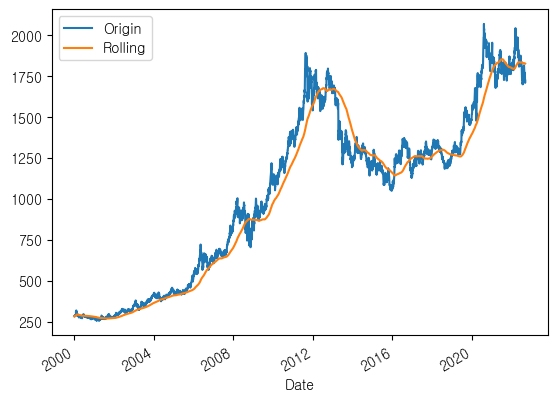

In [37]:
pd.DataFrame({'Origin' : df_gold['Close'], 'Rolling' :df_gold['Close'].rolling(window = '365D').mean()}).plot()
plt.show()

## 확장 윈도우(expanding windows)

윈도우 연산에서 `expanding()`은 이동하는 윈도우 기간의 크기를 점차적으로 늘려가는 방식이다. 윈도우 기간이 고정된 `rolling()`과 달리 `expanding()`은 데이터프레임에서 윈도우 창의 시작점을 고정하지 않고, 시작점을 점차적으로 늘려가면서 연산을 수행한다. 이를 통해 처음부터 현재까지의 모든 데이터를 기반으로 새로운 값들을 계산할 수 있다.

In [24]:
pd.DataFrame({'Origin' : df_GDP['Korea, Rep.'], 'Expanding' :df_GDP['Korea, Rep.'].expanding(3).sum()}).head(5)

,Origin,Expanding
year,,
1960-01-01,1027.468538,NaN
1961-01-01,1066.610515,NaN
1962-01-01,1076.920824,3170.999878
1963-01-01,1141.820659,4312.820537
1964-01-01,1217.726265,5530.546802


확장 윈도우도 롤링 윈도우와 같이 `agg()`를 사용하여 여러 개의 요약 함수를 동시에 사용할 수 있다. 하지만 `expanding()`은 달력상의 주기를 설정하여 사용할 수 없다는 점이 `rolling()`과 다르다.   

In [27]:
Origin_df = df_import[('중국', '무역수지')].to_frame().droplevel(level = 0, axis = 1)
Expanding_df = df_import[('중국', '무역수지')].expanding(3).agg(['mean', 'min', 'max']).round()
Origin_df.join(Expanding_df).head(5)

,무역수지,mean,min,max
2000-01-01,227050,NaN,NaN,NaN
2000-02-01,438827,NaN,NaN,NaN
2000-03-01,312029,325969.0,227050.0,438827.0
2000-04-01,334514,328105.0,227050.0,438827.0
2000-05-01,596630,381810.0,227050.0,596630.0
2000-06-01,553340,410398.0,227050.0,596630.0


# 날짜와 시간의 지연 연산

시계열 데이터가 다른 데이터와 가장 큰 차이는 날짜와 시간의 인덱스가 반드시 필요하다는 것이다. 이 날짜와 시간은 다른 데이터와는 달리 데이터의 순서가 정해져 있다는 특징이 존재한다. 다른 데이터 들도 데이터가 발생한 순서가 중요할 수 있지만 일반적으로는 그 순서 자체가 큰 의미가 없다. 하지만 시계열 데이터는 시간에 따라 순서가 정해져 있기 때문에 이 순서에 따른 연산도 가능하다. 

시계열 데이터의 순서에 따른 대표적인 연산이 지연(lag) 연산이다. 지연은 시계열 데이터에서 해당 데이터의 시점과 이전 시점 데이터를 비교하기 위해 사용하는 지연을 말한다.  지연은 시계열 데이터가 가지고 있는 일정한 주기의 과거 시점 데이터와의 패턴을 파악하고 예측하기 위해 중요한 연산이다. 특히 전년대비 증감율과 같은 데이터를 산출하기 위해서 사용되는 지연 연산의 대표적인 연산이 이동(shift)와 차분(diff) 연산이다.  

## 이동(shift) 연산

python에서 lag 연산을 위해서는 pandas의 `shift()`를 사용한다. `shift()` 함수는 시계열 데이터의 각 원소를 주어진 기간만큼 과거나 미래로 이동시키는 기능을 제공하는데, 매개변수로 'periods'와 'freq'를 설정할 때 결과가 달라진다. 다음은 `shift()`에서 사용하는 주요 매개변수이다. 
<div class="alert alert-success">
    
- periods : 이동시킬 기간을 정수로 지정, 양수인 경우 이전 방향으로 이동하며, 음수인 경우 다음 방향으로 이동
- freq : 시계열 데이터의 주기를 지정, 이 매개변수를 사용하면 시간 주기로 shift가 수행됨
- axis : shift 연산이 수행될 축의 지정, 0은 행 방향으로, 1은 열 방향으로 shift 됨
- fill_value : 누락 데이터의 대체 값 지정
    
</div>

### period를 사용한 이동

시계열 데이터는 그 데이터의 특성에 따라 일부 구간의 누락이 발생할 수 있다. 다만 이 누락이 데이터 자체적으로 인정되는 누락인지, 데이터가 손실되어 발생한 누락인지의 여부가 중요하다. 예를 들어 특정 점포의 판매량 데이터의 경우 해당 점포가 영업하지 않는 휴일의 경우에는 판매량 데이터가 누락되게 된다. 그러나 영업을 했음에도 판매량 데이터가 없다면 이는 데이터의 손실에 따른 비정상적인 데이터 손실로 봐야 할 것이다. 

이렇게 발생된 데이터들의 지연(lag) 연산을 하기 위해서는 `shift()`의 'periods' 매개변수를 사용해야 한다. 'periods'는 날짜와 시간의 간격에 상관없이 발생된 데이터들의 lag를 발생시킨다. 

다음은 1회차, 2회차의 lag가 발생된 두 개의 데이터프레임을 보이고 있다. 첫 번째 데이터에서는 연 간격으로 구성된 데이터이고 누락된 값이 없기 때문에 lag된 데이터도 누락없이 생성되었다. 그러나 두 번째 데이터는 주말에 해당하는 1월 8일과 1월 9일 데이터가 누락되었지만, 이와는 무관하게 데이터들이 lag 되었다.    

In [64]:
pd.DataFrame({'origin' : df_GDP['Korea, Rep.'], 'shifted_1' : df_GDP['Korea, Rep.'].shift(periods = 1), 
              'shifted_2' : df_GDP['Korea, Rep.'].shift(periods = 2)}).head(5)

,origin,shifted_1,shifted_2
year,,,
1960-01-01,1027.468538,NaN,NaN
1961-01-01,1066.610515,1027.468538,NaN
1962-01-01,1076.920824,1066.610515,1027.468538
1963-01-01,1141.820659,1076.920824,1066.610515
1964-01-01,1217.726265,1141.820659,1076.920824


In [66]:
pd.DataFrame({'origin' : df_gold['Close'], 'shifted_1' : df_gold['Close'].shift(periods = 1, fill_value=0), 
              'shifted_2' : df_gold['Close'].shift(periods = 2, fill_value=0)}).head(5)

,origin,shifted_1,shifted_2
Date,,,
2000-01-04,283.7,0.0,0.0
2000-01-05,282.1,283.7,0.0
2000-01-06,282.4,282.1,283.7
2000-01-07,282.9,282.4,282.1
2000-01-10,282.7,282.9,282.4


### freq를 사용하는 이동

앞선 금 가격의 데이터에서 2000년 1월 8, 9일 데이터는 누락되어 있다. 이 두 날은 토요일과 일요일에 해당하는 날로써 금 거래소에서 거래가 이루어지지 않은 날이다. 만약 이 날짜를 포함하여 lag 연산을 하기 위해서는 'periods' 매개변수 대신 'freq' 매개변수를 사용해야 한다. 'freq' 매개변수에는 을 설정할 수 있는데 'freq'에는 DateOffset, timedelta, 시간의 간격 문자열을 설정할 수 있다. 

다음은 일 간격으로 lag를 산출하는 `shift()`의 활용 예이다. 다음의 코드에서는 1일 간격으로 lag를 산출하는데 이로 인해 원 데이터에 없던 날짜인 2000년 1월 8일이 나타났다. 이 날은 1월 7일 데이터가 이동한 날이기 때문에 원 데이터 열에는 데이터가 없을을 뜻하는 'NaN'이 표현되었고 lag된 데이터는 1월 7일이었던 데이터가 표현되었다. 또 2000년 1월 10일의 데이터의 경우 일 기준의 lag 값은 1월 9일 데이터가 없기 때문에 'NaN'으로 표시되었다.  

In [29]:
pd.DataFrame({'origin' : df_gold['Close'], 'shifted_D' : df_gold['Close'].shift(freq='D')}).head(7)

,origin,shifted_D
Date,,
2000-01-04,283.7,NaN
2000-01-05,282.1,283.7
2000-01-06,282.4,282.1
2000-01-07,282.9,282.4
2000-01-08,NaN,282.9
2000-01-10,282.7,NaN
2000-01-11,284.4,282.7


'fraq'를 사용하는 방법 중 특이한 방법은 'infer' 옵션을 사용하는 방법이다. 'infer' 옵션은 shift()의 매개변수로 이동할 기간을 명기하지 않아도 자동으로 추론하여 이동할 기간을 결정하는 옵션이다. 예를 들어, 시리즈의 인덱스가 연도이고, 인덱스가 1년씩 증가한다고 가정하면, infer 옵션을 사용하면 shift의 기간을 다음 연도로 자동으로 결정한다.

In [30]:
pd.DataFrame({'origin' : df_GDP['Korea, Rep.'], 'infer' : df_GDP['Korea, Rep.'].shift(freq='infer')}).head(5)

,origin,infer
year,,
1960-12-31,1027.468538,NaN
1961-12-31,1066.610515,1027.468538
1962-12-31,1076.920824,1066.610515
1963-12-31,1141.820659,1076.920824
1964-12-31,1217.726265,1141.820659


## 차분(diff) 연산

앞선 shift 연산은 단순히 데이터를 이동하는 연산이다. 그렇다면 데이터를 이동하는 연산이 필요한 이유는 무엇일까? 시계열 데이터는 많은 경우 과거 데이터와의 비교를 통해 추세를 살펴보는 경우가 많다. 이를 위해서는 비교가 필요한 일정 주기로 shift된 데이터와 원 데이터의 차이를 살펴보아야 한다. shift 연산의 결과와 원 데이터의 차이를 다음과 같이 산출할 수 있다.  

In [30]:
df_GDP_shifted = pd.DataFrame({'origin' : df_GDP['Korea, Rep.'], 'shifted' : df_GDP['Korea, Rep.'].shift(periods = 2)})
df_GDP_shifted['Diff'] = df_GDP_shifted['origin'] - df_GDP_shifted['shifted']
df_GDP_shifted.head(5)

,origin,shifted,Diff
year,,,
1960-01-01,1027.468538,NaN,NaN
1961-01-01,1066.610515,NaN,NaN
1962-01-01,1076.920824,1027.468538,49.452286
1963-01-01,1141.820659,1066.610515,75.210144
1964-01-01,1217.726265,1076.920824,140.805441


하지만 pandas에서는 이와 같은 연산을 수행하는 함수인 `diff()`를 지원한다. `diff()`는 다음과 같이 산출할 수 있다. 

In [31]:
df_GDP_diff = pd.DataFrame({'origin' : df_GDP['Korea, Rep.']})
df_GDP_diff['Diff'] = df_GDP_diff.diff(2)
df_GDP_diff.head(5)

,origin,Diff
year,,
1960-01-01,1027.468538,NaN
1961-01-01,1066.610515,NaN
1962-01-01,1076.920824,49.452286
1963-01-01,1141.820659,75.210144
1964-01-01,1217.726265,140.805441


In [32]:
df_GDP_shifted.Diff.dropna().equals(df_GDP_diff.Diff.dropna())

True

# 결측치 보간(interpolate)

연도별 시계열 데이터나 분기별, 월별 시계열 데이터의 경우는 그 시간적 간격이 크기 때문에 측정치간의 결측치가 비교적 적지만 주별, 일별 데이터나 그보다 작은 시간간격의 시계열 데이터에는 중간 중간 측정값이 누락되어 있는 경우가 많다. 이렇게 일정한 간격으로 값이 있어야하는 시간 간격에 측정치가 누락된 것을 결측치(Missing Value)라고 한다.

시계열 데이터의 결측치는 데이터 분석의 정확성을 떨어뜨릴 수 있는데 이는 예측 분석에 있어 큰 문제가 될 수 있다. 또 시계열 데이터는 시계열 데이터가 가진 패턴을 파악하는 것이 중요한데 결측치가 많이 존재하면 이 패턴의 파악이 어려워 진다. 

사실 이러한 결측치는 시계열 데이터가 아닌 어떤 데이터 셋에서도 존재한다. 하지만 시계열 데이터에는 시간이라는 일정한 선형 변수를 지니기 때문에 다른 데이터 셋의 결측치와는 다소 다르게 처리된다.

따라서 이 결측치를 채우는 방법이 필요한데 이 방법을 보간법(interpolate)이라고 한다. pandas에서 결측치 보간을 위해 사용되는 메쏘드는 `interpolate()`이다. `interpolate()`는 NaN으로 누락된 데이터를 여러가지 방법을 사용하여 채우는데 다음은 `interpolate()`에서 제공하는 보간법이다.

<div class="alert alert-success">
    
- linear : 기본값으로 선형 보간법 사용(시점과 종점을 직선으로 잇고 그 사이 값을 사용)
- spline : 다항식 또는 스플라인을 사용하여 값을 보간, 이 옵션을 사용하려면 다항식의 차수가 필요
- time : 일정한 길이의 값으로 보간
- index, values: 인덱스의 값으로 보간
- pad : 앞선 값을 사용하여 보간
- ‘nearest’, ‘zero’ : 최근 값이나 0으로 보간
    </div>

앞서 가져온 금값 데이터는 주기가 영업일이기 때문에 주말에 해당하는 토요일, 일요일에는 데이터가 누락되어 있다. 만약 이 데이터를 일 간격으로 재설정하면 주말의 데이터가 NaN으로 설정되게 된다. 다음은 금값 데이터에 대해 NaN을 다양한 방법으로 보간하는 코드이고 보간된 데이터를 시각화한 결과를 보이고 있다. 

In [111]:
df_gold_origin = df_gold.asfreq('D').Close
df_gold_inter_linear = df_gold_origin.interpolate()
df_gold_inter_spline = df_gold_origin.interpolate(method = 'spline', order = 2)
df_gold_inter_time = df_gold_origin.interpolate(method = 'time')
df_gold_inter_nearest = df_gold_origin.interpolate(method = 'nearest')
df_gold_inter_zero = df_gold_origin.interpolate(method = 'zero')
df_gold_inter = pd.concat([df_gold_origin, df_gold_inter_linear, df_gold_inter_spline, df_gold_inter_time, df_gold_inter_nearest, df_gold_inter_zero], 
                          axis = 1, 
                          keys = ['Origin', 'linear', 'spline', 'time', 'nearest', 'zero']).head(10)


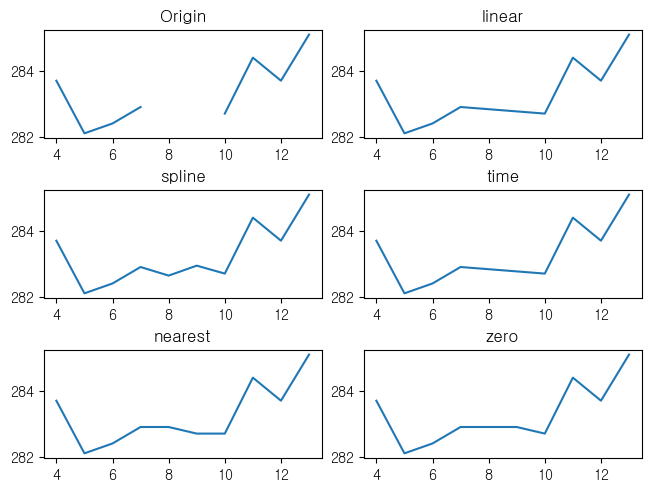

In [112]:
fig, axs = plt.subplots(nrows=3, ncols=2, constrained_layout=True)
axs[0, 0].plot(df_gold_inter.index.day, df_gold_inter.Origin)
axs[0, 0].set_title('Origin')
#axs[0, 0].xlabel('')
axs[0, 1].plot(df_gold_inter.index.day, df_gold_inter.linear)
axs[0, 1].set_title('linear')
axs[1, 0].plot(df_gold_inter.index.day, df_gold_inter.spline)
axs[1, 0].set_title('spline')
axs[1, 1].plot(df_gold_inter.index.day, df_gold_inter.time)
axs[1, 1].set_title('time')
axs[2, 0].plot(df_gold_inter.index.day, df_gold_inter.nearest)
axs[2, 0].set_title('nearest')
axs[2, 1].plot(df_gold_inter.index.day, df_gold_inter.zero)
axs[2, 1].set_title('zero')
plt.show()

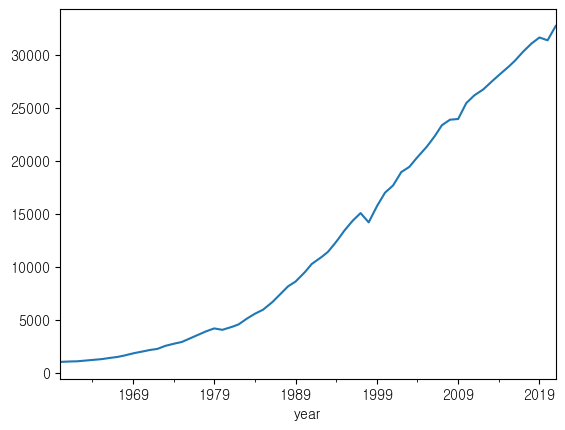

In [54]:
df_GDP['Korea, Rep.'].resample('MS').interpolate(method = 'time').plot()
plt.show()

# 날짜와 시간의 유용한 연산

## 날짜와 시간의 그룹화와 요약

실무에서 시계열 데이터를 사용할 때 아마도 가장 흔히 사용하는 연산은 특정 기간, 예를 들어 연도별 변동률, 분기별 판매량, 월별 수익률 등으로 요약한 데이터를 표나 그래프로 작성하여 보고서로 작성하는 것일 것이다. 이를 위해서는 먼저 시계열 데이터를 특정 기간별로 그룹화하고 이 그룹에 대해 요약 함수나 업무 로직이 구현된 함수를 적용하여 데이터를 요약한다. pandas에서는 이를 위해 `resample()`을 제공한다. 

`resmaple()`은 pandas에서 데이터를 요약할 때 사용하는 `groupby()`와 유사하다고 생각하면 이해가 쉽다. pandas의 `groupby()`는 데이터프레임의 열을 기준으로 데이터프레임을 그룹화하지만 `resample()`은 시계열 인덱스가 설정된 데이터프레임을 일정한 시간 주기로 설정한다. 또 `resample()`에는 몇 가지 유용한 매개 변수가 있다. 

다음은 `resample()`에서 사용하는 주요 매개변수이다. 

<div class="alert alert-success">
    
- rule : 리샘플링 날짜와 시간 간격
- closed : 리샘플링 시간 간격에서 시점을 포함시킬지(이상), 종점을 포함시킬지 여부(이하)를 설정
- label : 리샘플링 시간을 시점으로 표시할지, 종점으로 표시할지 설정
- kind : 시계열 인덱스를 DateTimeIndex로 사용할지('timestamp'), PeriodIndex로 사용할지('period') 설정
- on : 시계열 인덱스를 사용하지 않을 경우 리샘플링 기준 열 설정
</div>

`resample()`로 그룹화된 시계열 데이터에 대해 요약 통계 함수를 적용하면 그룹당 요약 통계값이 산출된다. 적용하는 요약 함수로 `sum()`, `mean()`, `std()`, `max()`, `min()` 등이 사용된다. 

In [14]:
df_GDP_3years = df_GDP.resample(rule = '3A', kind = 'period').mean().round()
df_GDP_3years.tail()

country,Canada,European Union,France,Germany,Italy,Japan,"Korea, Rep.",United Kingdom,United States,World
year,,,,,,,,,,
2008,41196.0,29269.0,35707.0,37410.0,32401.0,32717.0,24427.0,42700.0,52938.0,9188.0
2011,42400.0,29615.0,36210.0,40061.0,31224.0,33590.0,26752.0,42879.0,54146.0,9642.0
2014,43589.0,30456.0,36663.0,41212.0,30303.0,34863.0,28763.0,45046.0,56577.0,10146.0
2017,44784.0,32439.0,38262.0,42951.0,31651.0,36020.0,31000.0,46999.0,59504.0,10752.0
2020,43097.0,31972.0,36879.0,42188.0,30430.0,34924.0,32052.0,43600.0,60154.0,10750.0


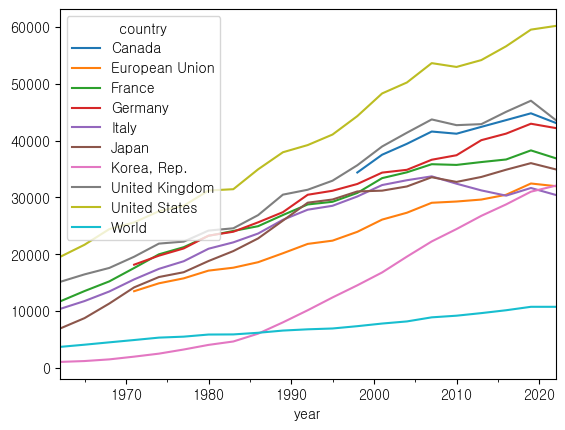

In [15]:
df_GDP_3years.plot()
plt.show()

In [17]:
df_import_quarter = df_import.loc[:, (df_import.columns.get_level_values(1)=='무역수지') & (df_import.columns.get_level_values(0)=='중국')].droplevel(level = 1, axis = 1).resample(rule = 'Q', kind = 'period').agg(['mean', 'max', 'min']).round()
df_import_quarter.tail()

국가             중국                  
             mean      max      min
2021Q4  1851157.0  2431228  1513454
2022Q1  1945999.0  3015779   191805
2022Q2  -558427.0   616341 -1197959
2022Q3  -110027.0   662949  -606776
2022Q4  -875835.0  -619588 -1254397

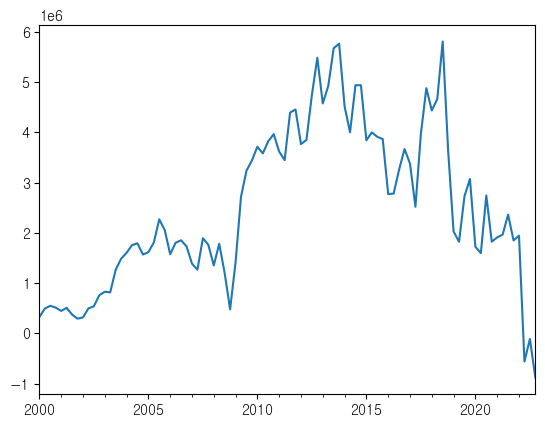

In [18]:
df_import_quarter[('중국', 'mean')].plot()
plt.show()

In [19]:
df_gold['Close'].resample(rule = 'W', kind = 'timestamp').agg(['mean', 'std']).tail().round()

,mean,std
Date,,
2022-08-07,1790.0,11.0
2022-08-14,1811.0,4.0
2022-08-21,1780.0,14.0
2022-08-28,1758.0,9.0
2022-09-04,1729.0,15.0


## OHLC 연산

시계열 데이터 특히 금융이나 재정과 관련된 시계열 연산에서 자주 사용되는 연산이 OHLC 연산이다. OHLC 연산은 특정 기간의 시가(Open), 고가(High), 저가(Low), 종가(Close)를 산출하는 연산으로 pandas에서 `ohlc()`를 사용하면 간단히 산출할 수 있다. OHLC 연산은 `resample()`과 함께 사용하는 것이 일반적인데, `resample()`로 설정한 리샘플 객체에 대해 `ohlc()`를 적용한다.  

In [124]:
df_GDP_period['Korea, Rep.'].resample('5Y').ohlc().tail()

,open,high,low,close
year,,,,
2000,16992.479076,20361.069254,16992.479076,20361.069254
2005,21193.357514,23948.472244,21193.357514,23948.472244
2010,25451.004155,28094.917703,25451.004155,28094.917703
2015,28732.231076,31640.214630,28732.231076,31640.214630
2020,31372.471261,32730.650628,31372.471261,32730.650628


In [129]:
df_gold['Close'].resample('3B').ohlc().tail()

,open,high,low,close
Date,,,,
2022-08-17,1776.7,1776.7,1762.9,1762.9
2022-08-22,1748.4,1761.5,1748.4,1761.5
2022-08-25,1771.4,1771.4,1749.7,1749.7
2022-08-30,1736.3,1736.3,1709.3,1709.3
2022-09-02,1723.0,1723.0,1723.0,1723.0


## 기간별 변동율 산출

앞서 윈도우 연산에서 사용했던 `diff()`는 주어진 기간 동안의 데이터 변동량을 구하는 함수로 보통 바로 직전 기간과 현재 기간의 차이를 통해 데이터의 변화 추세를 살펴보는 중요한 연산이다. 하지만 이 연산은 단순한 데이터의 변동량을 사용할 때도 있지만 직전 기간의 데이터에 대비한 변동량의 비율을 산출하여 사용하는 경우도 많다. 이를 변동율(Change Rate), 혹은 성장율(Growth Rate)이라고 한다.

변동율을 산출하는 공식은 다음과 같다. 

$$Growth\,rate(\%) = {(Value_{present} - Value_{past}) \over Value_{past}} \times 100$$ 

이 공식대로 변동율을 산출한다면 다음과 같이 산출할 수 있다. 

In [177]:
df_GDP_growth = df_GDP_period['Korea, Rep.'].to_frame()
df_GDP_growth['Past']= df_GDP_growth.shift()
df_GDP_growth['Diff']= df_GDP_growth['Korea, Rep.'].diff()
df_GDP_growth['Growth'] = df_GDP_growth['Diff'] / df_GDP_growth['Past'] * 100
df_GDP_growth

,"Korea, Rep.",Past,Diff,Growth
year,,,,
1960,1027.468538,NaN,NaN,NaN
1961,1066.610515,1027.468538,39.141977,3.809555
1962,1076.920824,1066.610515,10.310309,0.966642
1963,1141.820659,1076.920824,64.899835,6.026426
1964,1217.726265,1141.820659,75.905606,6.647770
...,...,...,...,...
2017,30307.395236,29461.784007,845.611229,2.870197
2018,31053.637929,30307.395236,746.242692,2.462246
2019,31640.214630,31053.637929,586.576701,1.888915


앞의 코드와 같이 shift와 diff 연산을 사용하면 변동율을 산출할 수 있다. 하지만 pandas에서는 `pct_change()`를 사용하여 간단히 변동율을 산출할 수 있다. 

In [192]:
df_GDP_growth_pctchange = df_GDP_period['Korea, Rep.'].to_frame()
df_GDP_growth_pctchange['Growth'] = df_GDP_growth_pctchange.pct_change().mul(100).round(2)
df_GDP_growth_pctchange

,"Korea, Rep.",Growth
year,,
1960,1027.468538,NaN
1961,1066.610515,3.81
1962,1076.920824,0.97
1963,1141.820659,6.03
1964,1217.726265,6.65
...,...,...
2017,30307.395236,2.87
2018,31053.637929,2.46
2019,31640.214630,1.89


shift와 diff를 사용하여 산출한 변동율과 `pct_change()`를 사용한 변동율은 같다. 

In [193]:
df_GDP_growth_pctchange['Growth'].dropna().equals(df_GDP_growth['Growth'].dropna().round(2))

True

## 변동률의 상관관계

상관관계는 두 변수 간의 선형적 관계를 설명하는 통계적 개념으로 독립 변수의 변동에 따른 종속 변수의 변화량을 설명한다. 이 상관관계는 보통 상관계수라는 수치로 표현될 수 있는데 이 상관계수가 높을 수록 두 변수간의 회귀 직선에 집중되어 있고 상관계수가 낮을 수록 회귀 직선에 분산되어 분포한다. 또 상관계수가 양수이면 데이터가 집중되는 직선이 우측 상향으로 그려지는 직선으로 독립 변수가 증가할수록 종속 변수가 증가하는 경향으로 분포하며, 상관계수가 음수이면 데이터가 집중되는 직선이 우측 하향으로 그려지는 직선으로 독립 변수가 증가할수록 종속 변수가 감소하는 경향으로 데이터가 분포한다. 

그러나 시계열 데이터의 경우에는 시계열 인덱스가 존재하기 때문에 시계열 데이터 자체에는 독립 변수인 시계열 인덱스와 시간의 변화에 따른 데이터 변화량인 종속 변수가 포함되어 있다. 따라서 시계열 데이터는 그 데이터 자체에서 상관관계가 있는 특징이 있는데 이를 자기 상관 관계라하고 이는 다음 장에서 다시 설명한다. 하지만 자기 시계열 데이터 자체가 가지는 상관관게가 아닌 두 개 이상의 시계열 데이터가 얼마나 유사한지를 판단하기 위해도 상관 관계를 사용할 수 있다. 두 개 이상의 시계열 데이터의 상관관계를 분석하기 위해서는 각각의 시계열 데이터에서 시간에 따른 종속을 제거하기 위해 데이터의 변동률을 사용한다. 각 각의 시계열 데이터에 대해 데이터 변동률을 `pct_change()`를 사용하여 산출하고, 이들의 데이터 변동률 쌍에 대해 pandas의 `corr()`를 사용하면 각 각 열들 간의 상관관계에 대한 상관계수가 산출된다. 이를 시각화하기 위해서는 seaborn에서 제공하는 `heatmap()`을 사용한다.  

다음은 각 국가의 연도별 GDP의 변화량에 대한 상관관계에 대한 히트맵을 그리는 코드이다. 

<AxesSubplot: xlabel='country', ylabel='country'>

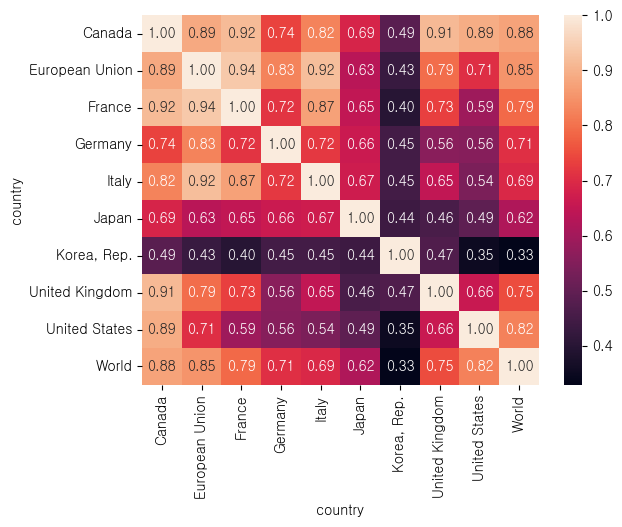

In [41]:
import seaborn as sns
df_GDP_return = df_GDP.pct_change()
df_GDP_corr = df_GDP_return.corr()
sns.heatmap(df_GDP_corr, annot = True, fmt = '.2f')

앞의 히트맵에서 살펴보면 전반적으로 유럽에 위치한 나라간의 시계열 데이터 변동률의 상관계수가 비교적 높게 나타난다. 또 북미에 위치한 미국과 캐나다가 높게 나타나지만 아시아에 위치한 우리나라와 일본과 타 대륙의 국가간의 상관 계수는 비교적 낮게 나타난다. 특히 우리나라의 상관 계수는 다른 나라와는 달리 0.5를 넘기지 못하는 것으로 나타난다. 그렇다면 이 중 상관 계수가 높게 나타난 프랑스와 캐나다, 상관 계수가 낮게 나타난 한국과 전세계 GDP 변화율에 대한 산점도를 그리면 다음과 같다.  

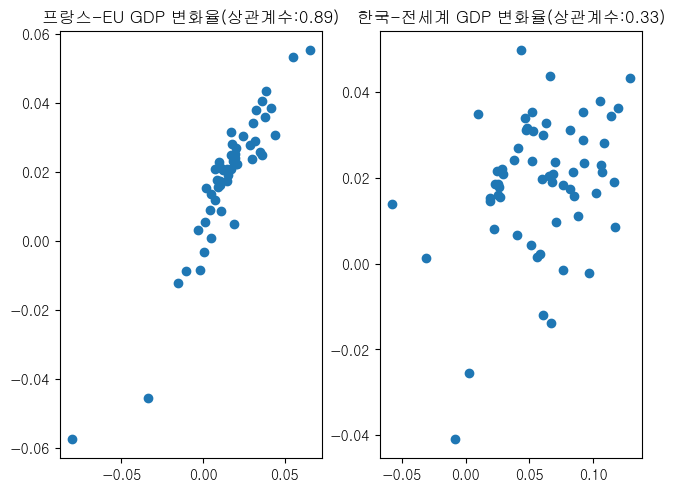

In [47]:
fig, axs = plt.subplots(nrows=1, ncols=2, constrained_layout=True)
axs[0].scatter(df_GDP_return['France'], df_GDP_return['European Union'])
axs[0].set_title('프랑스-EU GDP 변화율(상관계수:0.89)')
axs[1].scatter(df_GDP_return['Korea, Rep.'], df_GDP_return['World'])
axs[1].set_title('한국-전세계 GDP 변화율(상관계수:0.33)')
plt.show()

앞의 산점도에서도 보이듯이 상관계수가 높을수록 데이터가 회귀 직선의 주위에 집중되며 상관관계가 낮을수록 데이터가 전반적으로 퍼져있음을 볼 수 있다. 그렇다면 이들 시계열 데이터는 얼마나 유사한 흐름을 보이는지 다음의 그래프에서 비교해 볼 수 있다. 

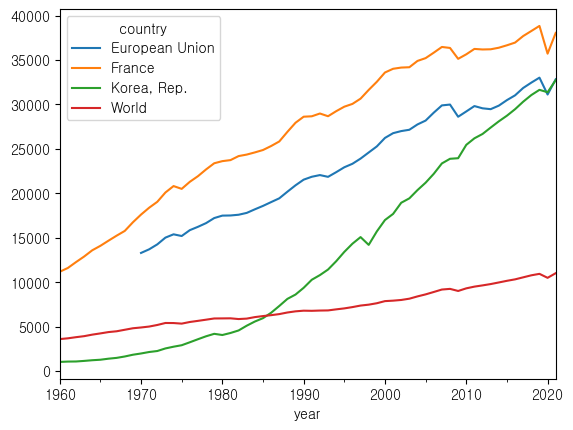

In [43]:
df_GDP[['European Union', 'France', 'Korea, Rep.', 'World']].plot()
plt.show()

앞의 그래프에서 보면 상관계수가 높은 프랑스와 EU의 시계열 데이터는 그 흐름의 패턴이 매우 유사하게 나오는 것을 볼 수 있다. 하지만 상관계수가 낮은 우리나라와 전세계 시계열 데이터는 그 흐름의 기울기나 특성이 확실히 다른 것을 볼 수 있다. 

다음은 우리나라의 국가별 수출금액의 변동율에 대한 상관계수를 보이고 있다. 

<AxesSubplot: xlabel='국가', ylabel='국가'>

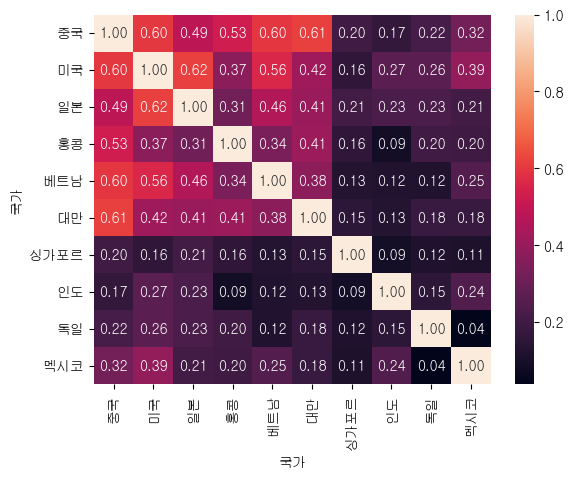

In [44]:
import seaborn as sns
df_import_monthly_price = df_import.loc[:, df_import.columns.get_level_values(1)=='수출금액'].droplevel(level = 1, axis = 1).resample(rule = 'M', kind = 'period').last()
df_import_monthly_return = df_import_monthly_price.pct_change()
df_import_monthly_corr = df_import_monthly_return.corr()
#df_import_quarter_corr
sns.heatmap(df_import_monthly_corr, annot = True, fmt = '.2f')

In [ ]:
이 중 변동률 상관계수가 높은 중국과 미국, 상관계수가 낮은 멕시코와 독일의 산점도와 시계열 그래프는 다음과 같다.  

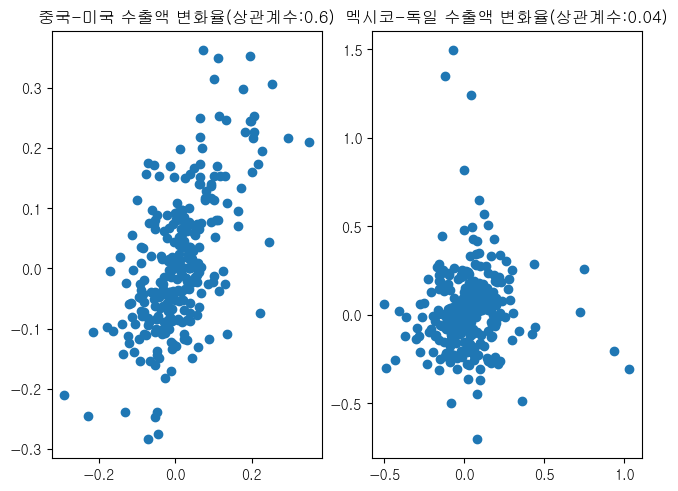

In [46]:
fig, axs = plt.subplots(nrows=1, ncols=2, constrained_layout=True)
axs[0].scatter(df_import_monthly_return['중국'], df_import_monthly_return['미국'])
axs[0].set_title('중국-미국 수출액 변화율(상관계수:0.6)')
axs[1].scatter(df_import_monthly_return['멕시코'], df_import_monthly_return['독일'])
axs[1].set_title('멕시코-독일 수출액 변화율(상관계수:0.04)')
plt.show()

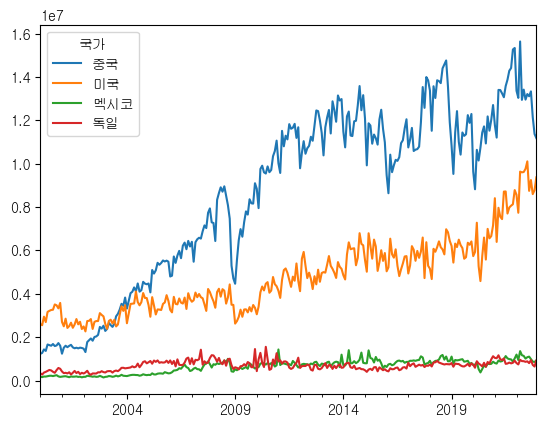

In [39]:
df_import_monthly_price[['중국', '미국', '멕시코', '독일']].plot()
plt.show()

## 기간 수익률과 누적 수익률

자산 투자를 해본 경험이 있다면 흔히 볼 수 있는 지표가 수익률 지표이다. 수익률은 일정 기간 동안 투자한 자산의 수익 혹은 손실에 대한 백분율 지표이다. 보통은 연간 수익률을 계산하지만 일간, 월간, 분기별 수익률을 계산하기도 한다. 또 자신의 투자 기간동안의 전체 수익률을 산출할 때는 누적 수익률을 사용한다. 

### 기간 수익률

기간 수익률은 설정된 기간의 이전 기간 대비 현재 기간의 비율을 말한다. 기간 수익률은 다음의 공식과 같이 산출할 수 있다. 

$$ Rate\,of\,Return(\%) = \left({Value_{present} \over Value_{past}} - 1\right) \times 100 $$ 

이는 앞서 설명한 `pct_change()`를 사용하면 간단히 산출될 수 있다. 만약 기간별 수익률을 산출한다면 `pct_change()`의 'periods'를 사용하여 기간을 설정할 수 있다. 다음은 금 가격의 30일 기간 수익률을 산출하는 코드이다. 

In [170]:
Pre = df_gold.Close
past_30 = df_gold.Close.shift(30)
Return_30 = df_gold.Close.pct_change(periods = 30)
Return_30 = pd.concat([Origin, Shift_30, Return_30], axis = 1, keys = ['Pre', 'Past_30', 'Return_30'])
Return_30.tail(5)

,Pre,Past_30,Return_30
Date,,,
2022-08-29,1749.7,1710.2,0.023097
2022-08-30,1736.3,1710.7,0.014965
2022-08-31,1726.2,1700.2,0.015292
2022-09-01,1709.3,1713.4,-0.002393
2022-09-02,1723.0,1727.4,-0.002547


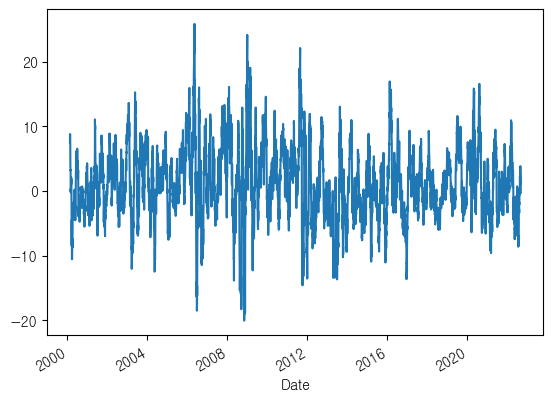

In [172]:
Return_30.Return_30.mul(100).plot()
plt.show()

### 누적 수익률

누적 수익률은 특정 기간 동안 투자한 자산의 수익률을 합산한 것이다. 누적 수익률은 초기 투자 금액에 대한 최종 수익률로써, 총 투자 기간 동안의 수익률의 변화를 표현하는데 사용된다. 예를 들어, 1년전 1000만원의 투자가 1년후 1100만원이되었다면 연간 수익률은 10%이다. 하지만 1년 후 1100만원이 될 때까지 월별 수익률은 오르고 내리고 할 것이다. 이와 같이 단위 기간의 수익률에 대한 기하 평균이 누적 수익률이다. 

누적 수익률은 다음과 같이 산출할 수 있다. 

$$ Cumulative\,Rate\,of\,Return = (1+r_1)(1+r_2)...(1+r_t) -1$$

위의 공식을 풀어보자면 각각의 기간별 수익률에 1을 더하고 이들에 대한 누적곱을 구한 후 다시 1을 뺀 것이다. python에서 누적곱은 `cumprod()`를 사용하는데 다음은 금 가격의 일별 수익률에 대한 누적 수익률을 산출하는 코드이다. 

In [180]:
Origin = df_gold.Close
Return = df_gold.Close.pct_change()
Cum_Return = Return.add(1).cumprod().sub(1)
Cum_Return = pd.concat([Origin, Return, Cum_Return], axis = 1, keys = ['Origin', 'Return', 'Cum_Return'])
Cum_Return.tail()

,Origin,Return,Cum_Return
Date,,,
2022-08-29,1749.7,-0.000057,5.167430
2022-08-30,1736.3,-0.007658,5.120197
2022-08-31,1726.2,-0.005817,5.084596
2022-09-01,1709.3,-0.009790,5.025026
2022-09-02,1723.0,0.008015,5.073317


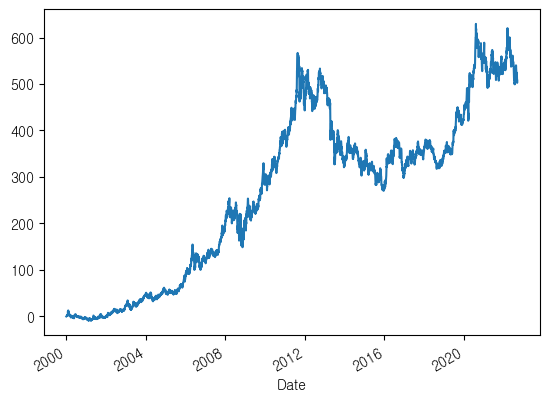

In [182]:
Cum_Return.Cum_Return.mul(100).plot()
plt.show()

앞의 코드로는 구간이 1인 수익률(`pct_change(periods=1)`)에 대한 누적 수익률을 구할 수 있지만 구간이 1 이상인 누적 수익률은 구할 수 없다. 따라서 다음과 같은 인라인 람다 함수를 사용하면 산출된다. 이 함수에는 산출하고자 하는 구간에 대한 롤링윈도우가 적용된 pandas Series의 각 원소에 대해 실행해야 한다. 이는 `apply()`를 통해 호출하면 특정 구간에 대한 누적 수익률을 산출할 수 있다. 

In [209]:
#def period_return(period_returns):
#    return np.prod(period_returns + 1) - 1

Origin = df_gold.Close
Return = df_gold.Close.pct_change()
#rolling_annual_returns = Return.rolling('365D').apply(period_return).mul(100)
rolling_annual_returns = Return.rolling('365D').apply(lambda period_returns: np.prod(period_returns + 1) - 1).mul(100)
rolling_annual_returns.tail(10)

Date
2022-08-22   -1.995516
2022-08-23   -2.496817
2022-08-24   -2.598839
2022-08-25   -1.094361
2022-08-26   -2.528966
2022-08-29   -3.836219
2022-08-30   -4.188279
2022-08-31   -5.054727
2022-09-01   -5.875551
2022-09-02   -4.885454
Name: Close, dtype: float64

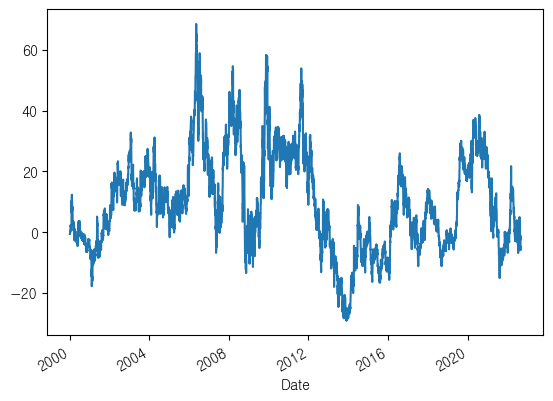

In [210]:
rolling_annual_returns.plot()
plt.show()